In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
    ConfusionMatrixDisplay
)

In [2]:
ROOT = Path.cwd()

MODEL_DIR = ROOT / "models"

DATA_DIR = ROOT / "data"

PROCESSED_DIR = DATA_DIR / "processed"

OUTPUT_DIR = ROOT / "outputs"

FIGURE_DIR = ROOT / "figures"

FIGURE_DIR.mkdir(exist_ok=True)

OUTPUT_DIR.mkdir(exist_ok=True)

In [6]:
##Load processed test data.##
test = pd.read_csv(

    PROCESSED_DIR /

    "test2.csv"

)

X_test = test.drop(

    columns=["loan_status"]

)

y_test = test["loan_status"]


In [7]:
##Load trained models.##
models = {

    "Logistic Regression":

        joblib.load(

            MODEL_DIR /

            "logistic.pkl"

        ),

    "Random Forest":

        joblib.load(

            MODEL_DIR /

            "random_forest.pkl"

        ),

    "XGBoost":

        joblib.load(

            MODEL_DIR /

            "xgboost.pkl"

        ),

    "LightGBM":

        joblib.load(

            MODEL_DIR /

            "lightgbm.pkl"

        ),

    "CatBoost":

        joblib.load(

            MODEL_DIR /

            "catboost.pkl"

        )

}

In [8]:
##Evaluate every model.##
results=[]

predictions={}

probabilities={}

for name,model in models.items():

    y_pred=model.predict(X_test)

    y_prob=model.predict_proba(X_test)[:,1]

    predictions[name]=y_pred

    probabilities[name]=y_prob

    results.append({

        "Model":name,

        "Accuracy":

            accuracy_score(

                y_test,

                y_pred

            ),

        "Precision":

            precision_score(

                y_test,

                y_pred

            ),

        "Recall":

            recall_score(

                y_test,

                y_pred

            ),

        "F1":

            f1_score(

                y_test,

                y_pred

            ),

        "AUC":

            roc_auc_score(

                y_test,

                y_prob

            ),

        "MCC":

            matthews_corrcoef(

                y_test,

                y_pred

            )

    })

results=pd.DataFrame(results)

results

,Model,Accuracy,Precision,Recall,F1,AUC,MCC
0,Logistic Regression,0.8405,0.861021,0.961795,0.908622,0.803186,0.327809
1,Random Forest,0.8425,0.857449,0.970285,0.910384,0.805943,0.323231
2,XGBoost,0.8400,0.860945,0.961189,0.908309,0.797298,0.326012
3,LightGBM,0.8375,0.860174,0.958763,0.906797,0.794599,0.315889
4,CatBoost,0.8450,0.861696,0.967253,0.911429,0.803234,0.344649


In [9]:
##Round results.##
results=results.round(4)

results

,Model,Accuracy,Precision,Recall,F1,AUC,MCC
0,Logistic Regression,0.8405,0.8610,0.9618,0.9086,0.8032,0.3278
1,Random Forest,0.8425,0.8574,0.9703,0.9104,0.8059,0.3232
2,XGBoost,0.8400,0.8609,0.9612,0.9083,0.7973,0.3260
3,LightGBM,0.8375,0.8602,0.9588,0.9068,0.7946,0.3159
4,CatBoost,0.8450,0.8617,0.9673,0.9114,0.8032,0.3446


In [10]:
##Save Table 2.##
results.to_csv(

    OUTPUT_DIR/

    "Table2_Model_Performance.csv",

    index=False

)

results

,Model,Accuracy,Precision,Recall,F1,AUC,MCC
0,Logistic Regression,0.8405,0.8610,0.9618,0.9086,0.8032,0.3278
1,Random Forest,0.8425,0.8574,0.9703,0.9104,0.8059,0.3232
2,XGBoost,0.8400,0.8609,0.9612,0.9083,0.7973,0.3260
3,LightGBM,0.8375,0.8602,0.9588,0.9068,0.7946,0.3159
4,CatBoost,0.8450,0.8617,0.9673,0.9114,0.8032,0.3446


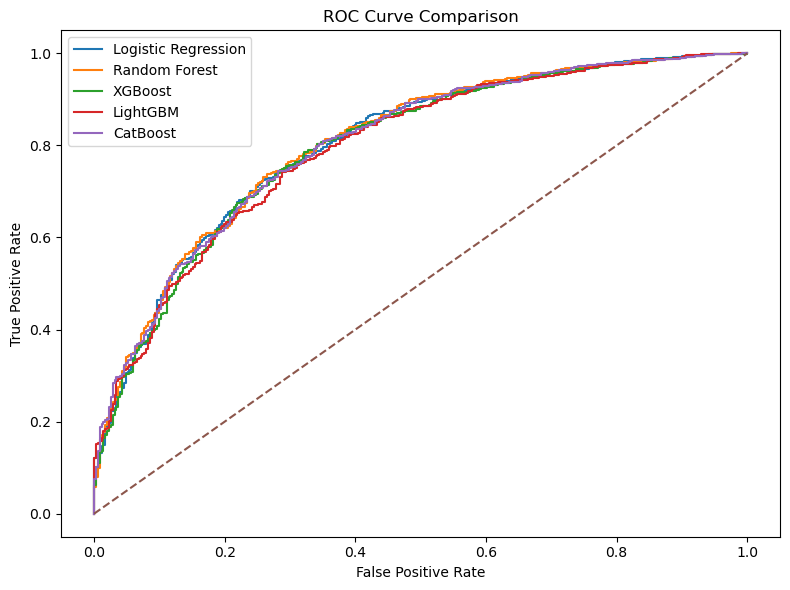

In [11]:
##Generate ROC Curve.##
plt.figure(figsize=(8,6))

for name in models.keys():

    fpr,tpr,_=roc_curve(

        y_test,

        probabilities[name]

    )

    plt.plot(

        fpr,

        tpr,

        label=name

    )

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(

    FIGURE_DIR/

    "Figure7_ROC.png",

    dpi=300

)

plt.show()

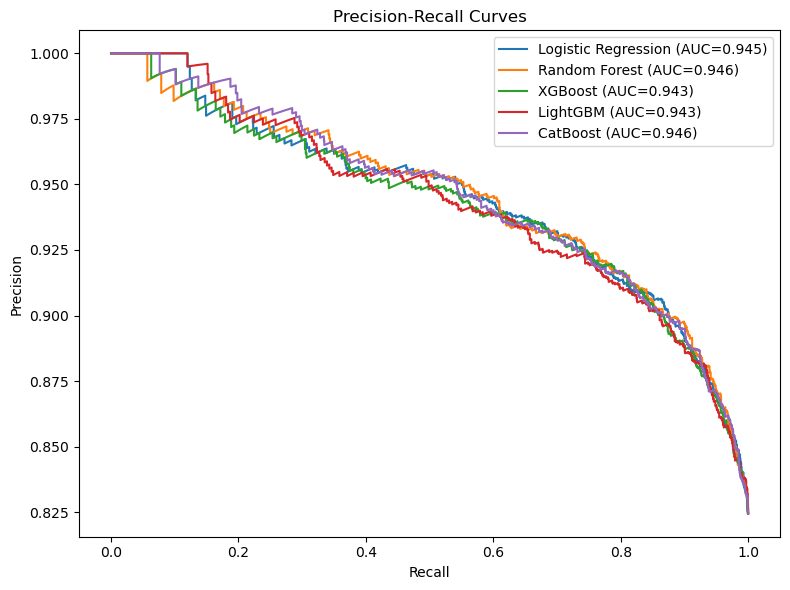

In [12]:
##Precision–Recall Curves.##
plt.figure(figsize=(8,6))

for name in models.keys():

    precision,recall,_=precision_recall_curve(

        y_test,

        probabilities[name]

    )

    pr_auc=auc(

        recall,

        precision

    )

    plt.plot(

        recall,

        precision,

        label=f"{name} (AUC={pr_auc:.3f})"

    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curves")

plt.legend()

plt.tight_layout()

plt.savefig(

    FIGURE_DIR/

    "Figure8_PR_Curve.png",

    dpi=300

)

plt.show()

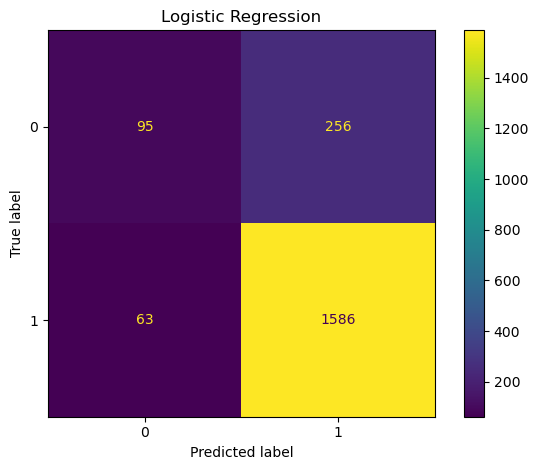

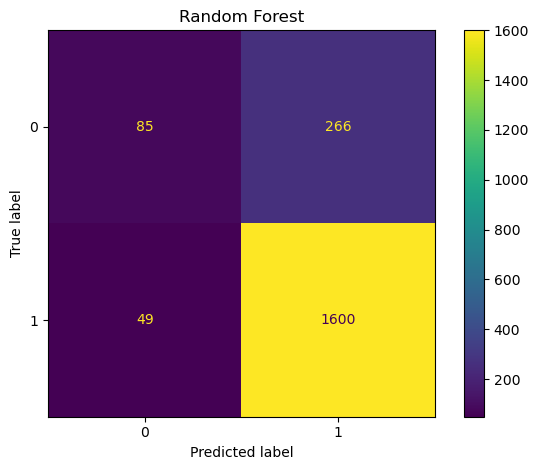

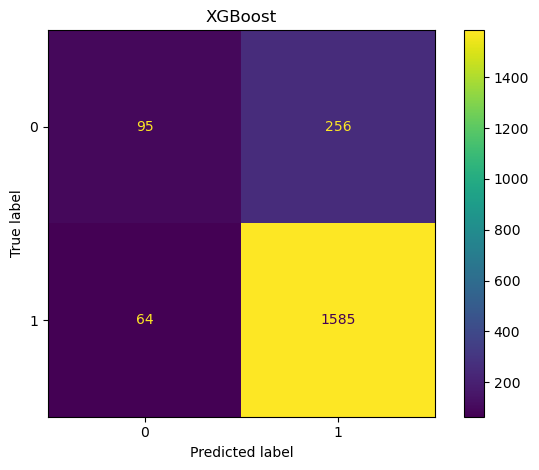

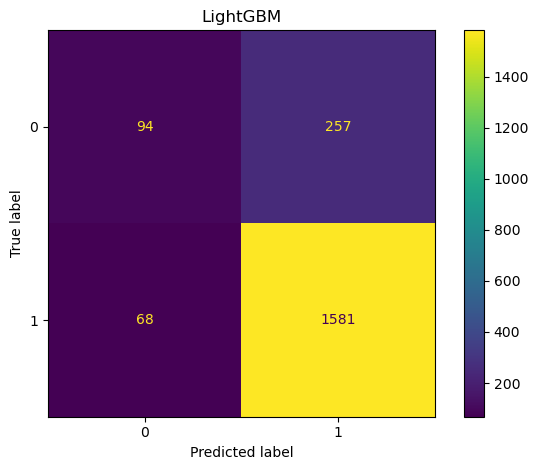

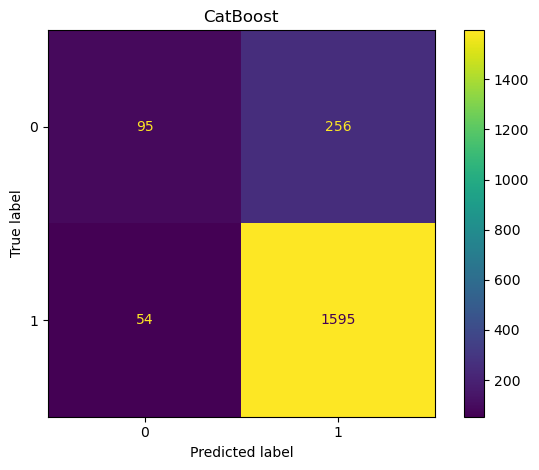

In [13]:
##Confusion Matrices.##
for name in models.keys():

    cm=confusion_matrix(

        y_test,

        predictions[name]

    )

    disp=ConfusionMatrixDisplay(

        confusion_matrix=cm

    )

    disp.plot()

    plt.title(name)

    plt.tight_layout()

    plt.savefig(

        FIGURE_DIR/

        f"{name}_Confusion_Matrix.png",

        dpi=300

    )

    plt.show()

In [14]:
##Classification Reports.##
for name in models.keys():

    print("="*70)

    print(name)

    print("="*70)

    print(

        classification_report(

            y_test,

            predictions[name]

        )

    )

Logistic Regression
              precision    recall  f1-score   support

           0       0.60      0.27      0.37       351
           1       0.86      0.96      0.91      1649

    accuracy                           0.84      2000
   macro avg       0.73      0.62      0.64      2000
weighted avg       0.82      0.84      0.81      2000

Random Forest
              precision    recall  f1-score   support

           0       0.63      0.24      0.35       351
           1       0.86      0.97      0.91      1649

    accuracy                           0.84      2000
   macro avg       0.75      0.61      0.63      2000
weighted avg       0.82      0.84      0.81      2000

XGBoost
              precision    recall  f1-score   support

           0       0.60      0.27      0.37       351
           1       0.86      0.96      0.91      1649

    accuracy                           0.84      2000
   macro avg       0.73      0.62      0.64      2000
weighted avg       0.81      0.8

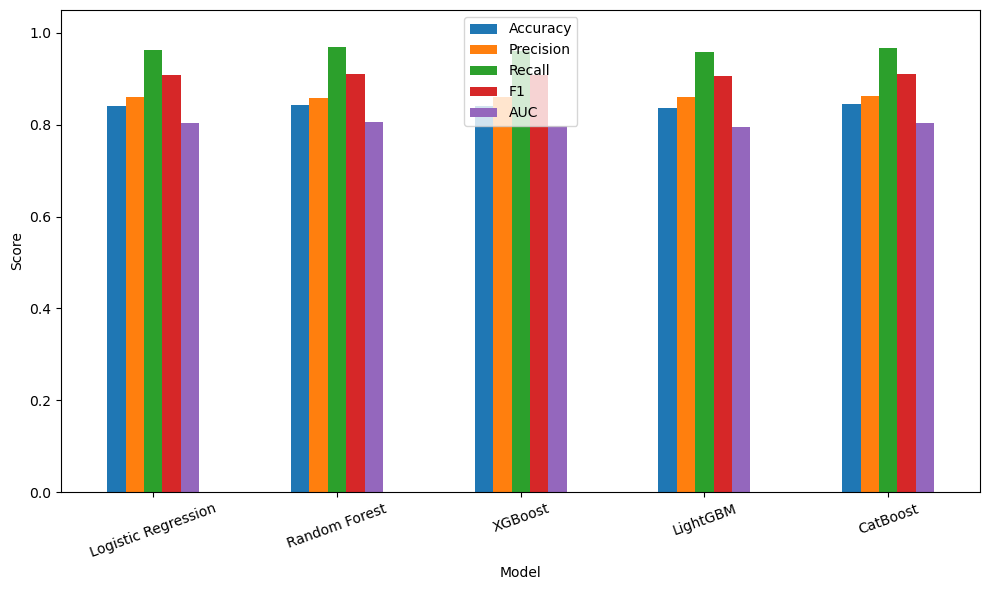

In [15]:
##Model Comparison Chart.##
metrics=["Accuracy","Precision","Recall","F1","AUC"]

comparison=results.set_index(

    "Model"

)[metrics]

comparison.plot(

    kind="bar",

    figsize=(10,6)

)

plt.ylabel("Score")

plt.ylim(0,1.05)

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(

    FIGURE_DIR/

    "Figure6_Model_Comparison.png",

    dpi=300

)

plt.show()

In [16]:
##Rank models.##
ranking=results.sort_values(

    "AUC",

    ascending=False

)

ranking

,Model,Accuracy,Precision,Recall,F1,AUC,MCC
1,Random Forest,0.8425,0.8574,0.9703,0.9104,0.8059,0.3232
0,Logistic Regression,0.8405,0.8610,0.9618,0.9086,0.8032,0.3278
4,CatBoost,0.8450,0.8617,0.9673,0.9114,0.8032,0.3446
2,XGBoost,0.8400,0.8609,0.9612,0.9083,0.7973,0.3260
3,LightGBM,0.8375,0.8602,0.9588,0.9068,0.7946,0.3159


In [17]:
##Export final ranking.##
ranking.to_csv(

    OUTPUT_DIR/

    "Model_Ranking.csv",

    index=False

)

print("="*70)

print("NOTEBOOK 04 COMPLETE")

print("="*70)

print()

print("Generated")

print("----------------")

print("Table2_Model_Performance.csv")

print("Model_Ranking.csv")

print("Figure6_Model_Comparison.png")

print("Figure7_ROC.png")

print("Figure8_PR_Curve.png")

print("Confusion Matrices")

NOTEBOOK 04 COMPLETE

Generated
----------------
Table2_Model_Performance.csv
Model_Ranking.csv
Figure6_Model_Comparison.png
Figure7_ROC.png
Figure8_PR_Curve.png
Confusion Matrices
